# Capítulo 5 — ¿Cómo se miden la frecuencia de la enfermedad y el riesgo de enfermar?

**Basado en el capítulo de Juan de Mata Donado Campos** ([PDF original](https://www.proyectosame.com/brotes/Apoyo/Bibliograf%C3%ADa/20.%20Medidas%20de%20frecuencia.pdf))

Este notebook explica:

1. Conceptos básicos: razón, proporción, tasa
2. Tipos de población (transversal, cohorte fija, dinámica)
3. Medidas de incidencia (tasa/densidad, incidencia acumulada, método actuarial)
4. Análisis de supervivencia (Kaplan-Meier, Cutler-Ederer)
5. Prevalencia (puntual y de período)
6. Relación entre incidencia y prevalencia
7. Derivaciones del anexo (método de densidad y actuarial)

Para el análisis de supervivencia (Kaplan-Meier, tablas de vida) usaremos **[`lifelines`](https://lifelines.readthedocs.io/)**, el paquete estándar de Python para este tipo de análisis.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.utils import survival_table_from_events

plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.float_format', '{:.4f}'.format)

---
## 5.0 Introducción: conceptos básicos

Los epidemiólogos estudian la **frecuencia** de los eventos de salud, es decir, la relación entre el número de casos y el tamaño de la población. Antes de entrar en las medidas de frecuencia propiamente dichas, hay que aclarar tres conceptos:

### 5.0.1 Razón

Una **razón** es el cociente entre dos cantidades: `a/b` o "a es a b". Las tasas, proporciones y porcentajes son tipos particulares de razones.

- **Rango:** 0 → ∞
- Puede tener dimensión (camas por 100.000 hab.) o no (hombres/mujeres).

**Ejemplo:** Índice de Masa Corporal = peso(kg) / estatura(m)²

In [18]:
def imc(peso_kg, estatura_m):
    return peso_kg / estatura_m**2

print(f"IMC de una persona de 70 kg y 1.75 m: {imc(70, 1.75):.2f}")

hombres, mujeres = 14, 16
print(f"Razón Hombres:Mujeres = {hombres}:{mujeres} = {hombres/mujeres:.3f}")

IMC de una persona de 70 kg y 1.75 m: 22.86
Razón Hombres:Mujeres = 14:16 = 0.875


### 5.0.2 Proporción

Una **proporción** es una razón en la que el numerador **está incluido** en el denominador. Es adimensional y su rango es [0, 1] o [0, 100%].

$$P = \frac{a}{a+b}$$

**Ejemplo (letalidad):** probabilidad de morir de una enfermedad tras el diagnóstico.

In [19]:
def letalidad(fallecidos, diagnosticados):
    return fallecidos / diagnosticados

# Ejemplo: 45 fallecimientos entre 300 pacientes diagnosticados
L = letalidad(45, 300)
print(f"Letalidad = {L:.3f} = {L*100:.1f}%")

Letalidad = 0.150 = 15.0%


### 5.0.3 Tasa

Una **tasa** es un tipo de razón que incluye una medida de **tiempo** en el denominador. Mide la velocidad con la que aparece un evento.

$$\text{Tasa} = \frac{\text{nº eventos en un período}}{\text{persona-tiempo}} \times 10^n$$

- **Dimensión:** 1/Tiempo
- **Rango:** 0 → ∞

Todas las tasas son razones, pero no todas las razones son tasas. La tasa de mortalidad infantil, por ejemplo, es en realidad una **razón** (el numerador incluye niños nacidos el año anterior).

### 5.0.4 Tipos de población base

| Tipo | Descripción |
|---|---|
| **Transversal** | Observación en un único momento |
| **Longitudinal — Cohorte fija** | No entran individuos nuevos tras iniciar el seguimiento |
| **Longitudinal — Cohorte cerrada** | Cohorte fija **sin** abandonos |
| **Longitudinal — Dinámica/abierta** | Pueden entrar y salir individuos |
| **Estable/estacionaria** | Dinámica donde tamaño y distribución permanecen constantes |

---
## 5.3 Medidas de incidencia

La **incidencia** es el número de casos nuevos en un lugar y período. Responde a tres preguntas:

1. ¿A qué **velocidad** aparecen los casos? → **Tasa / densidad de incidencia**
2. ¿Cuál es el **riesgo** en un momento dado? → **Incidencia acumulada** / **método actuarial**
3. ¿Cuál es el **riesgo en un período**? → método de densidad, tablas de vida, Kaplan-Meier

### Dataset

Seguimiento de 30 personas desde su nacimiento hasta el 31 de diciembre de 1986.

In [3]:
# Tabla 1 del PDF: 30 personas
# sexo: V/M; año_nac; año_evento; edad; persona_tiempo; estado:
#   'E' = desarrolla enfermedad, 'A' = abandono, 'S' = sano al final
data = [
    (1, 'V', 1945, 1968, 23, 22.5, 'E'),
    (2, 'M', 1956, 1974, 18, 17.5, 'E'),
    (3, 'V', 1924, 1978, 54, 53.5, 'E'),
    (4, 'M', 1932, 1978, 46, 45.5, 'E'),
    (5, 'M', 1919, 1954, 35, 34.5, 'E'),
    (6, 'V', 1930, 1978, 48, 47.5, 'S'),
    (7, 'M', 1909, 1965, 56, 55.5, 'E'),
    (8, 'V', 1951, 1986, 35, 35.0, 'S'),
    (9, 'V', 1943, 1962, 19, 18.5, 'E'),
    (10,'M', 1934, 1968, 34, 33.5, 'E'),
    (11,'V', 1965, 1978, 13, 12.5, 'E'),
    (12,'M', 1954, 1975, 21, 20.5, 'A'),
    (13,'V', 1936, 1958, 22, 21.5, 'E'),
    (14,'M', 1950, 1986, 36, 35.5, 'E'),
    (15,'M', 1943, 1962, 19, 18.5, 'E'),
    (16,'V', 1913, 1986, 73, 73.0, 'S'),
    (17,'M', 1931, 1967, 36, 35.5, 'A'),
    (18,'V', 1967, 1979, 12, 11.5, 'E'),
    (19,'M', 1926, 1985, 59, 58.5, 'E'),
    (20,'V', 1921, 1974, 53, 52.5, 'E'),
    (21,'M', 1962, 1979, 17, 16.5, 'E'),
    (22,'M', 1966, 1986, 20, 20.0, 'S'),
    (23,'V', 1929, 1973, 44, 43.5, 'E'),
    (24,'M', 1953, 1985, 32, 31.5, 'E'),
    (25,'V', 1960, 1979, 19, 18.5, 'E'),
    (26,'M', 1957, 1986, 29, 29.0, 'S'),
    (27,'V', 1943, 1963, 20, 19.5, 'A'),
    (28,'V', 1955, 1985, 30, 29.5, 'E'),
    (29,'M', 1929, 1975, 46, 45.5, 'E'),
    (30,'M', 1953, 1986, 33, 33.0, 'A'),
]
df = pd.DataFrame(data, columns=['id','sexo','nac','evento','edad','pt','estado'])
# 'evento_obs' = 1 si desarrolla enfermedad, 0 si censurado (abandono o sano)
df['evento_obs'] = (df['estado']=='E').astype(int)
print(f"Total: {len(df)} personas | Casos: {df.evento_obs.sum()} | "
      f"Abandonos: {(df.estado=='A').sum()} | Sanos al final: {(df.estado=='S').sum()}")
print(f"Suma persona-tiempo: {df.pt.sum()} años")
df.head()

Total: 30 personas | Casos: 21 | Abandonos: 4 | Sanos al final: 5
Suma persona-tiempo: 989.5 años


,id,sexo,nac,evento,edad,pt,estado,evento_obs
0,1,V,1945,1968,23,22.5000,E,1
1,2,M,1956,1974,18,17.5000,E,1
2,3,V,1924,1978,54,53.5000,E,1
3,4,M,1932,1978,46,45.5000,E,1
4,5,M,1919,1954,35,34.5000,E,1


### Tabla 2: agregación por grupos de edad

In [4]:
def grupo_edad(e):
    if e <= 20: return '11-20'
    if e <= 30: return '21-30'
    if e <= 40: return '31-40'
    if e <= 50: return '41-50'
    return '51 y más'

df['grupo'] = df['edad'].apply(grupo_edad)
orden = ['11-20','21-30','31-40','41-50','51 y más']

tabla2 = df.groupby('grupo').agg(
    n_personas=('id','count'),
    n_casos=('evento_obs','sum'),
    suma_pt=('pt','sum'),
    n_abandonos=('estado', lambda s: (s=='A').sum())
).reindex(orden)
tabla2.loc['Total'] = tabla2.sum()
tabla2

,n_personas,n_casos,suma_pt,n_abandonos
grupo,,,,
11-20,9.0000,7.0000,153.0000,1.0000
21-30,5.0000,3.0000,123.0000,1.0000
31-40,7.0000,4.0000,238.5000,2.0000
41-50,4.0000,3.0000,182.0000,0.0000
51 y más,5.0000,4.0000,293.0000,0.0000
Total,30.0000,21.0000,989.5000,4.0000


### 5.3.1 Densidad de incidencia (Ec. 5.4)

$$\text{DI} = \frac{\text{casos nuevos}}{\text{persona-tiempo}}$$

Expresa la **velocidad** con la que la enfermedad cambia el estado de salud. Es una medida **instantánea** (en la práctica, media).

In [8]:
tabla3 = tabla2.copy()
tabla3['DI'] = tabla3['n_casos'] / tabla3['suma_pt']
tabla3[['n_casos','suma_pt','DI']]

,n_casos,suma_pt,DI
grupo,,,
11-20,7.0000,153.0000,0.0458
21-30,3.0000,123.0000,0.0244
31-40,4.0000,238.5000,0.0168
41-50,3.0000,182.0000,0.0165
51 y más,4.0000,293.0000,0.0137
Total,21.0000,989.5000,0.0212


**Interpretación** (grupo 11–20): aparecen 0.046 casos por persona-año. Si siguiéramos 1000 jóvenes durante un año, esperaríamos ~46 casos.

#### Tiempo medio hasta el evento

$$T_\text{medio} = \frac{1}{\text{DI}}

In [20]:
tabla3['T_medio_evento'] = 1 / tabla3['DI']
tabla3[['DI','T_medio_evento']]

,DI,T_medio_evento
grupo,,
11-20,0.0458,21.8571
21-30,0.0244,41.0000
31-40,0.0168,59.6250
41-50,0.0165,60.6667
51 y más,0.0137,73.2500
Total,0.0212,47.1190


Para el grupo 11–20: DI=0.046 ⇒ cada 21.86 años aparece 1 caso.

### 5.3.2 Riesgo en un momento dado

#### 5.3.2.1 Incidencia acumulada (Ec. 5.12)

$$\text{IA} = \frac{I}{N_0}$$

donde $N_0$ = personas en riesgo al principio del seguimiento.


In [21]:
tabla6 = tabla2.copy()
tabla6['IA'] = tabla6['n_casos'] / tabla6['n_personas']
tabla6[['n_personas','n_casos','n_abandonos','IA']].round(3)

,n_personas,n_casos,n_abandonos,IA
grupo,,,,
11-20,9.0000,7.0000,1.0000,0.7780
21-30,5.0000,3.0000,1.0000,0.6000
31-40,7.0000,4.0000,2.0000,0.5710
41-50,4.0000,3.0000,0.0000,0.7500
51 y más,5.0000,4.0000,0.0000,0.8000
Total,30.0000,21.0000,4.0000,0.7000


#### Probabilidad de supervivencia y odds (Ec. 5.14)

$$S = 1 - \text{IA} \qquad \text{odds} = \frac{\text{IA}}{1-\text{IA}}$$

La **probabilidad acumulada de supervivencia** es el producto de las $S_i$ en cada intervalo (esto es, ya, el estimador de Kaplan-Meier).

In [22]:
tabla7 = tabla6[['n_personas','n_casos']].loc[orden].copy()
tabla7['IA'] = tabla7['n_casos'] / tabla7['n_personas']
tabla7['S_cond'] = 1 - tabla7['IA']
tabla7['S_acum'] = tabla7['S_cond'].cumprod()
tabla7['odds'] = tabla7['IA'] / tabla7['S_cond']
tabla7.round(4)

,n_personas,n_casos,IA,S_cond,S_acum,odds
grupo,,,,,,
11-20,9.0000,7.0000,0.7778,0.2222,0.2222,3.5000
21-30,5.0000,3.0000,0.6000,0.4000,0.0889,1.5000
31-40,7.0000,4.0000,0.5714,0.4286,0.0381,1.3333
41-50,4.0000,3.0000,0.7500,0.2500,0.0095,3.0000
51 y más,5.0000,4.0000,0.8000,0.2000,0.0019,4.0000


#### 5.3.3.3 Método del producto-límite — Kaplan-Meier


**Convenciones de `lifelines.KaplanMeierFitter`:**
- `durations` = tiempo observado de cada sujeto
- `event_observed` = 1 si ocurrió el evento, 0 si censurado (abandono o seguimiento terminado sin evento)

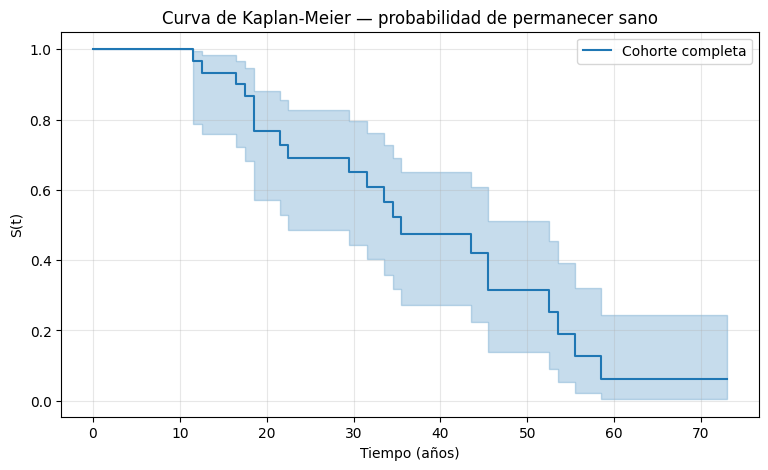

Mediana del tiempo hasta el evento: 35.5 años


In [23]:
kmf = KaplanMeierFitter()
kmf.fit(durations=df['pt'], event_observed=df['evento_obs'], label='Cohorte completa')

ax = kmf.plot_survival_function()
ax.set_title('Curva de Kaplan-Meier — probabilidad de permanecer sano')
ax.set_xlabel('Tiempo (años)')
ax.set_ylabel('S(t)')
ax.grid(True, alpha=0.3)
plt.show()

print(f"Mediana del tiempo hasta el evento: {kmf.median_survival_time_} años")

In [24]:
# Tabla de supervivencia completa de lifelines
tabla_surv = survival_table_from_events(df['pt'], df['evento_obs'])
tabla_surv.head(15)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0000,0,0,0,30,30
11.5000,1,1,0,0,30
12.5000,1,1,0,0,29
16.5000,1,1,0,0,28
17.5000,1,1,0,0,27
18.5000,3,3,0,0,26
19.5000,1,0,1,0,23
20.0000,1,0,1,0,22
20.5000,1,0,1,0,21


Columnas: `removed` = salidas (evento+censuras), `observed` = eventos, `censored` = censuras, `entrance` = entradas, `at_risk` = en riesgo al inicio del instante.

### 5.3.5 Relación cuantitativa entre tasa y riesgo

$$R = 1 - e^{-\text{DI} \cdot t}$$

Para valores pequeños de DI·t (<0.1), una aproximación lineal: $R \approx \text{DI} \cdot t$.

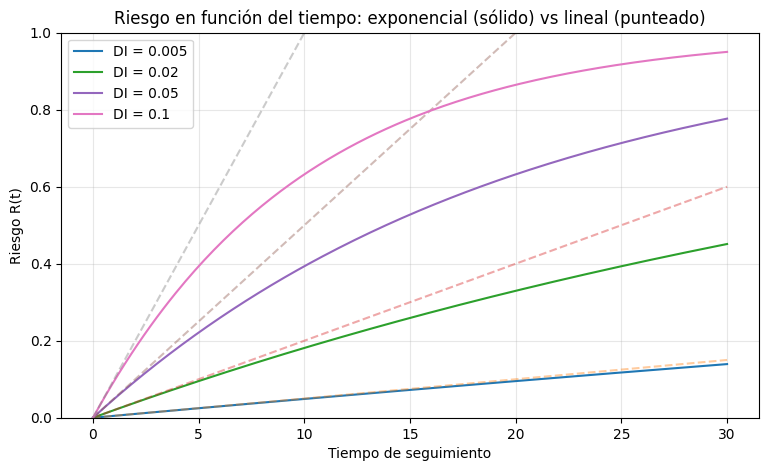

In [25]:
t = np.linspace(0, 30, 200)
fig, ax = plt.subplots()
for di in [0.005, 0.02, 0.05, 0.1]:
    ax.plot(t, 1 - np.exp(-di*t), label=f'DI = {di}')
    ax.plot(t, di*t, '--', alpha=0.4)
ax.set_xlabel('Tiempo de seguimiento')
ax.set_ylabel('Riesgo R(t)')
ax.set_title('Riesgo en función del tiempo: exponencial (sólido) vs lineal (punteado)')
ax.set_ylim(0, 1)
ax.legend(); ax.grid(alpha=0.3)
plt.show()

---
## Resumen

| Pregunta | Medida | Fórmula | Herramienta Python |
|---|---|---|---|
| ¿A qué velocidad aparecen los casos? | Densidad de incidencia | $I / \text{PT}$ | Cálculo directo |
| ¿Riesgo en un momento? (cohorte cerrada) | Incidencia acumulada | $I / N_0$ | Cálculo directo |
| ¿Riesgo con abandonos? | Método actuarial | $I / (N_0 - \text{Ab}/2)$ | Cálculo directo |
| ¿Riesgo en un período (constante)? | Método de densidad | $1 - e^{-\text{DI}\,t}$ | `numpy` |
| ¿Riesgo por intervalos con censuras? | Cutler-Ederer | $1 - \prod(1-\text{IA}_j)$ | `lifelines` (life_table) |
| ¿Riesgo individual sin categorizar? | Kaplan-Meier | producto-límite | `lifelines.KaplanMeierFitter` |
| ¿Cuántos enfermos hay ahora? | Prevalencia puntual | $C_t / N_t$ | Cálculo directo |
| Relación en equilibrio | Odds de prevalencia | $P/(1-P) = \text{DI}\,\bar D$ | Cálculo directo |

### El paquete `lifelines`

[`lifelines`](https://lifelines.readthedocs.io/) es el paquete de Python más usado para análisis de supervivencia. Implementa:

- **`KaplanMeierFitter`** — estimador del producto-límite (5.3.3.3)
- **`NelsonAalenFitter`** — estima la *hazard function* acumulada (relacionada con la tasa instantánea de 5.3.1)
- **`CoxPHFitter`**, **`WeibullFitter`**, etc. — modelos paramétricos y semi-paramétricos
- **`survival_table_from_events`** — construye tablas de vida estilo Cutler-Ederer
